<a href="https://colab.research.google.com/github/jay-nakrani/image-segmantation/blob/main/ACCURACY_FIXED_NOTEBOOK_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Import Libraries

In [ ]:
!pip install tensorflow opencv-python matplotlib numpy pillow scikit-learn pycocotools seaborn -q

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pycocotools.coco import COCO
import skimage.io as io
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import jaccard_score, f1_score
import os

%matplotlib inline

# Set random seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('✓ Libraries imported')

✓ Libraries imported


## Step 2: Define Color Scheme

In [ ]:
class_colors_rgb = {
    0: [0, 0, 0],              # background - BLACK
    1: [255, 0, 0],            # person - RED
    2: [0, 255, 0],            # car - GREEN
    3: [0, 0, 255],            # book - BLUE
    4: [255, 255, 0]           # airplane - YELLOW
}

target_classes = ["person", "car", "book", "airplane"]
class_names = ['background'] + target_classes

def convert_mask_to_colored_image(mask, class_colors_rgb):
    colored = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_id, rgb_color in class_colors_rgb.items():
        mask_pixels = (mask == class_id)
        colored[mask_pixels] = rgb_color
    return colored

print('✓ Color scheme defined')

✓ Color scheme defined


## Step 3: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
print('✓ Google Drive mounted')

Mounted at /content/drive
✓ Google Drive mounted


## Step 4: Setup Paths

In [ ]:
base_path = "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350"

train_data_path = os.path.join(base_path, "train")
train_annotation_file = os.path.join(base_path, "instances_train.json")

val_data_path = os.path.join(base_path, "val")
val_annotation_file = os.path.join(base_path, "instances_val.json")

test_data_path = os.path.join(base_path, "test")

print('✓ Paths configured')

✓ Paths configured


## Step 5: Load COCO Data

In [ ]:
print('Loading COCO annotations...')
coco_train = COCO(train_annotation_file)
coco_val = COCO(val_annotation_file)

category_IDs = coco_train.getCatIds()
categories = coco_train.loadCats(category_IDs)

print(f'✓ COCO loaded - {len(categories)} categories')

Loading COCO annotations...
loading annotations into memory...
Done (t=1.33s)
creating index...
index created!
loading annotations into memory...
Done (t=0.61s)
creating index...
index created!
✓ COCO loaded - 100 categories


## Step 6: Helper Functions

In [ ]:
def get_category_name(class_ID, categories):
    for cat in categories:
        if cat["id"] == class_ID:
            return cat["name"]
    return "None"

def create_mask(image_info, annotations_list, coco_api, target_classes):
    height = image_info["height"]
    width = image_info["width"]
    mask = np.zeros((height, width), dtype=np.uint8)

    for annotation in annotations_list:
        class_name = get_category_name(annotation["category_id"], categories)
        if class_name not in target_classes:
            continue

        pixel_value = target_classes.index(class_name) + 1
        ann_mask = coco_api.annToMask(annotation)
        mask = np.maximum(ann_mask * pixel_value, mask)

    return mask

print('✓ Helper functions defined')

✓ Helper functions defined


## Step 7: Filter Images

In [ ]:
target_classes_IDs = coco_train.getCatIds(catNms=target_classes)

print("Training images:")
training_images = []
for class_name in target_classes:
    cat_ids = coco_train.getCatIds(catNms=class_name)
    img_ids = coco_train.getImgIds(catIds=cat_ids)
    images = coco_train.loadImgs(img_ids)
    print(f'  {class_name}: {len(img_ids)}')
    training_images += images

unique_training_images = []
for img in training_images:
    if img not in unique_training_images:
        unique_training_images.append(img)
random.shuffle(unique_training_images)

print(f'Unique: {len(unique_training_images)}')

Training images:
  person: 233
  car: 148
  book: 51
  airplane: 5
Unique: 350


In [ ]:
print("Validation images:")
validation_images = []
for class_name in target_classes:
    cat_ids = coco_val.getCatIds(catNms=class_name)
    img_ids = coco_val.getImgIds(catIds=cat_ids)
    images = coco_val.loadImgs(img_ids)
    print(f'  {class_name}: {len(img_ids)}')
    validation_images += images

unique_validation_images = []
for img in validation_images:
    if img not in unique_validation_images:
        unique_validation_images.append(img)
random.shuffle(unique_validation_images)

print(f'Unique: {len(unique_validation_images)}')

Validation images:
  person: 239
  car: 136
  book: 46
  airplane: 7
Unique: 350


## Step 8: Create Dataset

In [ ]:
IMAGE_SIZE = 256

def load_and_process_image(image_path, image_info):
    image = io.imread(image_path)
    # Ensure 3-channel RGB (some ADE20K/COCO-style images are grayscale or RGBA)
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 4:
        image = image[:, :, :3]
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0
    return image

def load_and_process_mask(mask):
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
    return mask

def create_dataset(image_list, data_path, coco_api, categories, target_classes, verbose_errors=True):
    images = []
    masks = []
    skipped = 0

    for idx, img_info in enumerate(image_list):
        img_path = os.path.join(data_path, img_info['file_name'])

        if os.path.exists(img_path):
            try:
                image = load_and_process_image(img_path, img_info)

                ann_ids = coco_api.getAnnIds(
                    imgIds=img_info['id'],
                    catIds=coco_api.getCatIds(catNms=target_classes),
                    iscrowd=None
                )
                annotations = coco_api.loadAnns(ann_ids)
                mask = create_mask(img_info, annotations, coco_api, target_classes)
                mask = load_and_process_mask(mask)

                images.append(image)
                masks.append(mask)
            except Exception as e:
                skipped += 1
                if verbose_errors:
                    print(f'  [skipped] {img_info["file_name"]}: {e}')
        else:
            skipped += 1
            if verbose_errors:
                print(f'  [missing file] {img_path}')

        if (idx + 1) % 50 == 0:
            print(f'  {idx + 1}/{len(image_list)}')

    if skipped:
        print(f'  -> skipped {skipped}/{len(image_list)} images (see reasons above)')

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.int32)

print('Processing training data...')
X_train, y_train = create_dataset(
    unique_training_images, train_data_path, coco_train, categories, target_classes
)

print('\nProcessing validation data...')
X_val, y_val = create_dataset(
    unique_validation_images, val_data_path, coco_val, categories, target_classes
)

print(f'\nX_train: {X_train.shape} (dtype: {X_train.dtype})')
print(f'y_train: {y_train.shape} (dtype: {y_train.dtype}) - values: {np.unique(y_train)}')
print(f'X_val: {X_val.shape} (dtype: {X_val.dtype})')
print(f'y_val: {y_val.shape} (dtype: {y_val.dtype}) - values: {np.unique(y_val)}')


Processing training data...
  50/350
  100/350
  150/350
  200/350
  250/350
  300/350
  350/350

Processing validation data...
  50/350
  100/350
  150/350
  200/350
  250/350
  300/350
  350/350

X_train: (350, 256, 256, 3) (dtype: float32)
y_train: (350, 256, 256) (dtype: int32) - values: [0 1 2 3 4]
X_val: (350, 256, 256, 3) (dtype: float32)
y_val: (350, 256, 256) (dtype: int32) - values: [0 1 2 3 4]


## Step 9: EDA

=== CLASS DISTRIBUTION ===
person      :     915231 ( 59.5%)
car         :     497388 ( 32.3%)
book        :     106090 (  6.9%)
airplane    :      19864 (  1.3%)


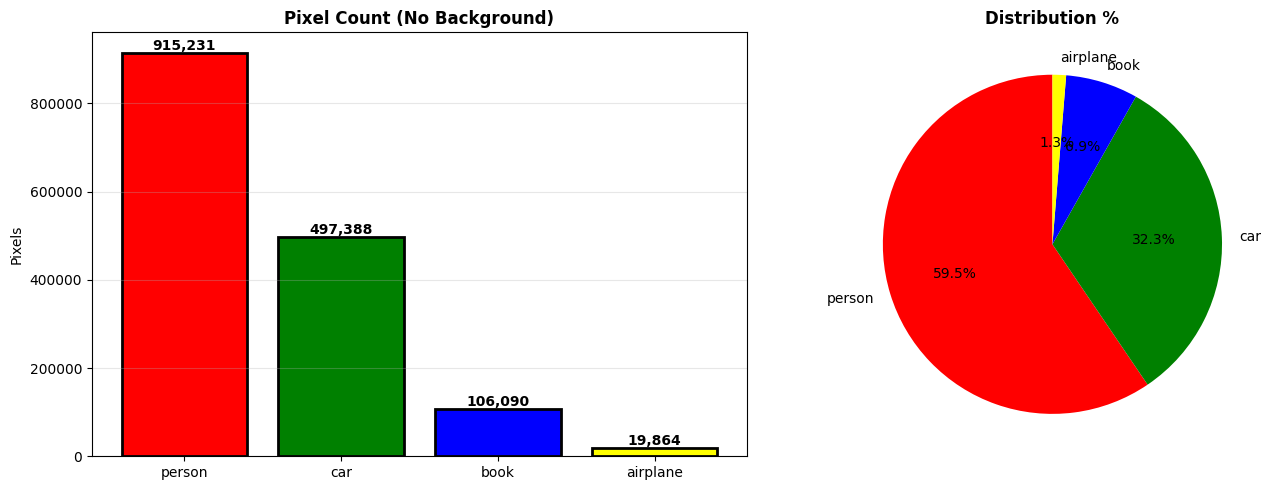

In [ ]:
print('=== CLASS DISTRIBUTION ===')
target_class_pixels = {}
for class_id, class_name in enumerate(target_classes, start=1):
    count = (y_train == class_id).sum()
    target_class_pixels[class_name] = count

for class_name, count in sorted(target_class_pixels.items(), key=lambda x: x[1], reverse=True):
    total = sum(target_class_pixels.values())
    pct = (count / total) * 100
    print(f'{class_name:12s}: {count:10d} ({pct:5.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = list(target_class_pixels.keys())
pixels = list(target_class_pixels.values())
colors = ['red', 'green', 'blue', 'yellow']

axes[0].bar(classes, pixels, color=colors, edgecolor='black', linewidth=2)
axes[0].set_title('Pixel Count (No Background)', fontweight='bold')
axes[0].set_ylabel('Pixels')
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(pixels):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', fontweight='bold')

total = sum(pixels)
percentages = [(p/total)*100 for p in pixels]
axes[1].pie(percentages, labels=classes, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution %', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 10: Build Improved U-Net (with regularization)

In [ ]:
def build_unet_improved(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=5):
    """
    Improved U-Net with:
    - Batch Normalization (stabilizes training)
    - L2 Regularization (prevents overfitting)
    - A single light Dropout at the bottleneck (0.2) -- kept minimal and in one
      place only. A previous attempt added dropout in 3 places plus heavier
      augmentation plus a shorter patience all at once, and that combination
      undertrained (val_mean_iou 0.26 vs 0.33 in this simpler version, because
      early stopping cut training off before the model adapted to the extra
      regularization). One small change at a time from here.
    """
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Dropout(0.2)(c4)

    # Decoder
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(u5)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c5)
    c5 = layers.BatchNormalization()(c5)

    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c6)
    c6 = layers.BatchNormalization()(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                       kernel_regularizer=regularizers.l2(1e-4))(c7)
    c7 = layers.BatchNormalization()(c7)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c7)

    return keras.Model(inputs=inputs, outputs=outputs)

model = build_unet_improved()
print('✓ Improved U-Net built (single light dropout at bottleneck)')
model.summary()

✓ Improved U-Net built (single light dropout at bottleneck)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 1,952,645 (7.45 MB)

 Trainable params: 1,949,829 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Step 11: Calculate Class Weights

In [ ]:
print('\n=== CLASS WEIGHTS ===')
class_counts = {}
for class_id in range(5):
    count = (y_train == class_id).sum()
    class_counts[class_id] = count

total_pixels = sum(class_counts.values())

# Lowered from 20 -> 8. Oversampling (next cell) now does most of the work of
# balancing class *exposure*; keeping the per-pixel weight this high on top of
# oversampling double-corrects and pushes the model to over-predict foreground
# everywhere (this is exactly what caused the precision collapse: person prec
# 0.16, car prec 0.17, book prec 0.03 in the previous run -- huge false-positive
# blobs, not genuine detections).
MAX_CLASS_WEIGHT = 8.0

class_weights = {}
for class_id, count in class_counts.items():
    raw_weight = total_pixels / (5 * max(count, 1))
    class_weights[class_id] = float(min(raw_weight, MAX_CLASS_WEIGHT))

print(f'{"class":12s} | {"pixels":>10s} | {"raw weight":>10s} | {"capped weight":>13s}')
for class_id, weight in class_weights.items():
    raw_weight = total_pixels / (5 * max(class_counts[class_id], 1))
    print(f'{class_names[class_id]:12s} | {class_counts[class_id]:10d} | {raw_weight:10.2f} | {weight:13.4f}')



=== CLASS WEIGHTS ===
class        |     pixels | raw weight | capped weight
background   |   21399027 |       0.21 |        0.2144
person       |     915231 |       5.01 |        5.0124
car          |     497388 |       9.22 |        8.0000
book         |     106090 |      43.24 |        8.0000
airplane     |      19864 |     230.95 |        8.0000


In [ ]:
print('\n=== OVERSAMPLING RARE-CLASS IMAGES ===')

image_class_presence = [set(np.unique(m)) - {0} for m in y_train]  # exclude background
class_image_counts = {c: sum(1 for s in image_class_presence if c in s) for c in range(1, 5)}

print('Training images containing each class:')
for c in range(1, 5):
    print(f'  {class_names[c]:12s}: {class_image_counts[c]:4d} / {len(y_train)} images')

max_count = max(class_image_counts.values())
# Lowered from 6 -> 3. A 6x cap combined with weighted loss caused the model to
# effectively memorise the handful of unique book/airplane images rather than
# generalise (visible as huge, wrongly-placed foreground blobs on unrelated
# test images). A gentler oversample + a gentler loss weight is more stable.
MAX_OVERSAMPLE = 3

repeat_factor_per_class = {
    c: min(MAX_OVERSAMPLE, max(1, round(max_count / max(class_image_counts[c], 1))))
    for c in class_image_counts
}
print('\nRepeat factor per class (capped at', MAX_OVERSAMPLE, '):')
for c in range(1, 5):
    print(f'  {class_names[c]:12s}: x{repeat_factor_per_class[c]}')

oversampled_indices = []
for i, classes_present in enumerate(image_class_presence):
    rep = max([repeat_factor_per_class[c] for c in classes_present], default=1)
    oversampled_indices.extend([i] * rep)

random.shuffle(oversampled_indices)

X_train_os = X_train[oversampled_indices]
y_train_os = y_train[oversampled_indices]

print(f'\nOriginal training set: {len(X_train)} images')
print(f'Oversampled training set: {len(X_train_os)} images')

new_presence = [set(np.unique(m)) - {0} for m in y_train_os]
new_counts = {c: sum(1 for s in new_presence if c in s) for c in range(1, 5)}
print('\nImages containing each class AFTER oversampling:')
for c in range(1, 5):
    print(f'  {class_names[c]:12s}: {new_counts[c]:4d} / {len(y_train_os)} images')



=== OVERSAMPLING RARE-CLASS IMAGES ===
Training images containing each class:
  person      :  233 / 350 images
  car         :  148 / 350 images
  book        :   51 / 350 images
  airplane    :    5 / 350 images

Repeat factor per class (capped at 3 ):
  person      : x1
  car         : x2
  book        : x3
  airplane    : x3

Original training set: 350 images
Oversampled training set: 606 images

Images containing each class AFTER oversampling:
  person      :  329 / 606 images
  car         :  300 / 606 images
  book        :  153 / 606 images
  airplane    :   15 / 606 images


## Step 12: Compile with Early Stopping

In [ ]:
NUM_CLASSES = 5

def make_weighted_ce_dice_loss(class_weights_dict, num_classes=5, dice_weight=0.5, smooth=1e-6):
    """Per-pixel weighted cross-entropy + weighted soft Dice loss.
    Dice keeps producing useful gradient on rare classes even once CE has
    plateaued, which is what's needed for classes with very few examples
    (book, airplane) rather than just tuning class_weight magnitudes further."""
    weights_vec = tf.constant([class_weights_dict[c] for c in range(num_classes)], dtype=tf.float32)
    weights_norm = weights_vec / tf.reduce_sum(weights_vec)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.cast(tf.one_hot(y_true, depth=num_classes), tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # weighted per-pixel cross-entropy
        ce_map = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)          # (B,H,W)
        pixel_weight = tf.reduce_sum(y_true_oh * weights_vec, axis=-1)              # (B,H,W)
        weighted_ce = tf.reduce_mean(ce_map * pixel_weight)

        # weighted soft Dice (per class, then combined with the same class weights)
        intersection = tf.reduce_sum(y_true_oh * y_pred, axis=[0, 1, 2])
        union = tf.reduce_sum(y_true_oh, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2])
        dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
        weighted_dice = tf.reduce_sum(weights_norm * dice_per_class)
        dice_loss_val = 1.0 - weighted_dice

        return weighted_ce + dice_weight * dice_loss_val

    return loss_fn

# dice_weight lowered from 1.0 -> 0.5: full-strength Dice on top of weighted CE
# and oversampling was over-correcting toward foreground (low precision everywhere).
combined_loss = make_weighted_ce_dice_loss(class_weights, num_classes=NUM_CLASSES, dice_weight=0.5)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=combined_loss,
    metrics=['accuracy', keras.metrics.MeanIoU(num_classes=NUM_CLASSES, sparse_y_pred=False, name='mean_iou')]
)

print('✓ Model compiled')
print('\nTraining Configuration:')
print('  - Loss: weighted per-pixel CE + weighted soft Dice (handles rare-class collapse)')
print('  - Oversampling: ENABLED for images containing rare classes')
print(f'  - Class weights (capped): {class_weights}')
print('  - Batch Norm / L2 Regularization: ENABLED')
print('  - Data augmentation: flip + brightness jitter (train only)')
print('  - Early Stopping (patience=10) + ReduceLROnPlateau: ENABLED')


✓ Model compiled

Training Configuration:
  - Loss: weighted per-pixel CE + weighted soft Dice (handles rare-class collapse)
  - Oversampling: ENABLED for images containing rare classes
  - Class weights (capped): {0: 0.21437984072827238, 1: 5.012417630084645, 2: 8.0, 3: 8.0, 4: 8.0}
  - Batch Norm / L2 Regularization: ENABLED
  - Data augmentation: flip + brightness jitter (train only)
  - Early Stopping (patience=10) + ReduceLROnPlateau: ENABLED


## Step 13: Train with Early Stopping

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

BATCH_SIZE = 16

def augment(image, mask):
    do_flip = tf.random.uniform(()) > 0.5
    image = tf.cond(do_flip, lambda: tf.reverse(image, axis=[1]), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.reverse(mask, axis=[1]), lambda: mask)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train_os, y_train_os))
train_ds = train_ds.shuffle(buffer_size=len(X_train_os), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Monitoring val_mean_iou (not val_loss) from here on: the loss now mixes a
# weighted CE term and a Dice term whose relative scale changes whenever the
# weights are tuned, so "best val_loss" isn't reliably "best segmentation".
# val_mean_iou is the metric we actually care about and is comparable across runs.
early_stop = EarlyStopping(
    monitor='val_mean_iou',
    mode='max',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mean_iou',
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print('Starting training...\n')

history = model.fit(
    train_ds,
    epochs=80,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

model.save('segmentation_model_fixed.keras')
print('\n✓ Model saved!')


Starting training...

Epoch 1/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.3132 - loss: 1.5311 - mean_iou: 0.0865 - val_accuracy: 0.9306 - val_loss: 1.7266 - val_mean_iou: 0.1862 - learning_rate: 5.0000e-04
Epoch 2/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 402ms/step - accuracy: 0.3928 - loss: 1.3561 - mean_iou: 0.1110 - val_accuracy: 0.9311 - val_loss: 1.7203 - val_mean_iou: 0.1862 - learning_rate: 5.0000e-04
Epoch 3/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 411ms/step - accuracy: 0.4703 - loss: 1.3040 - mean_iou: 0.1327 - val_accuracy: 0.9311 - val_loss: 1.8550 - val_mean_iou: 0.1862 - learning_rate: 5.0000e-04
Epoch 4/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 392ms/step - accuracy: 0.5118 - loss: 1.2604 - mean_iou: 0.1449 - val_accuracy: 0.9311 - val_loss: 2.0139 - val_mean_iou: 0.1862 - learning_rate: 5.0000e-04
Epoch 5/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 383ms/step - accuracy: 0.5397 - loss: 1.2164 - mean_iou: 0.1554 - val_accuracy: 0.9311 - val_loss: 1.8754 - val_mean_iou: 0.1862 - learning_ra

## Step 14: Analyze Training Results

In [ ]:
print('\n=== TRAINING ANALYSIS ===')
print(f'Total epochs trained: {len(history.history["loss"])}')
print(f'Initial training loss: {history.history["loss"][0]:.4f}')
print(f'Final training loss: {history.history["loss"][-1]:.4f}')
print(f'Initial validation loss: {history.history["val_loss"][0]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'\nBest validation loss: {min(history.history["val_loss"]):.4f}')
print(f'Best validation accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Final validation accuracy: {history.history["val_accuracy"][-1]:.4f}')

if 'val_mean_iou' in history.history:
    print(f'Best validation mean IoU: {max(history.history["val_mean_iou"]):.4f}')
    print(f'Final validation mean IoU: {history.history["val_mean_iou"][-1]:.4f}')
    print('(Mean IoU across all 5 classes, including background -- a much more honest')
    print(' measure than accuracy when classes are imbalanced.)')

if history.history['val_loss'][-1] < history.history['val_loss'][0]:
    print('✓ Validation loss improved')
else:
    print('✗ Validation loss did not improve -- inspect the loss curve below')



=== TRAINING ANALYSIS ===
Total epochs trained: 52
Initial training loss: 1.5311
Final training loss: 0.4677
Initial validation loss: 1.7266
Final validation loss: 1.2589

Best validation loss: 1.0704
Best validation accuracy: 0.9311
Final validation accuracy: 0.9015
Best validation mean IoU: 0.3212
Final validation mean IoU: 0.3147
(Mean IoU across all 5 classes, including background -- a much more honest
 measure than accuracy when classes are imbalanced.)
✓ Validation loss improved


## Step 15: Plot Training History

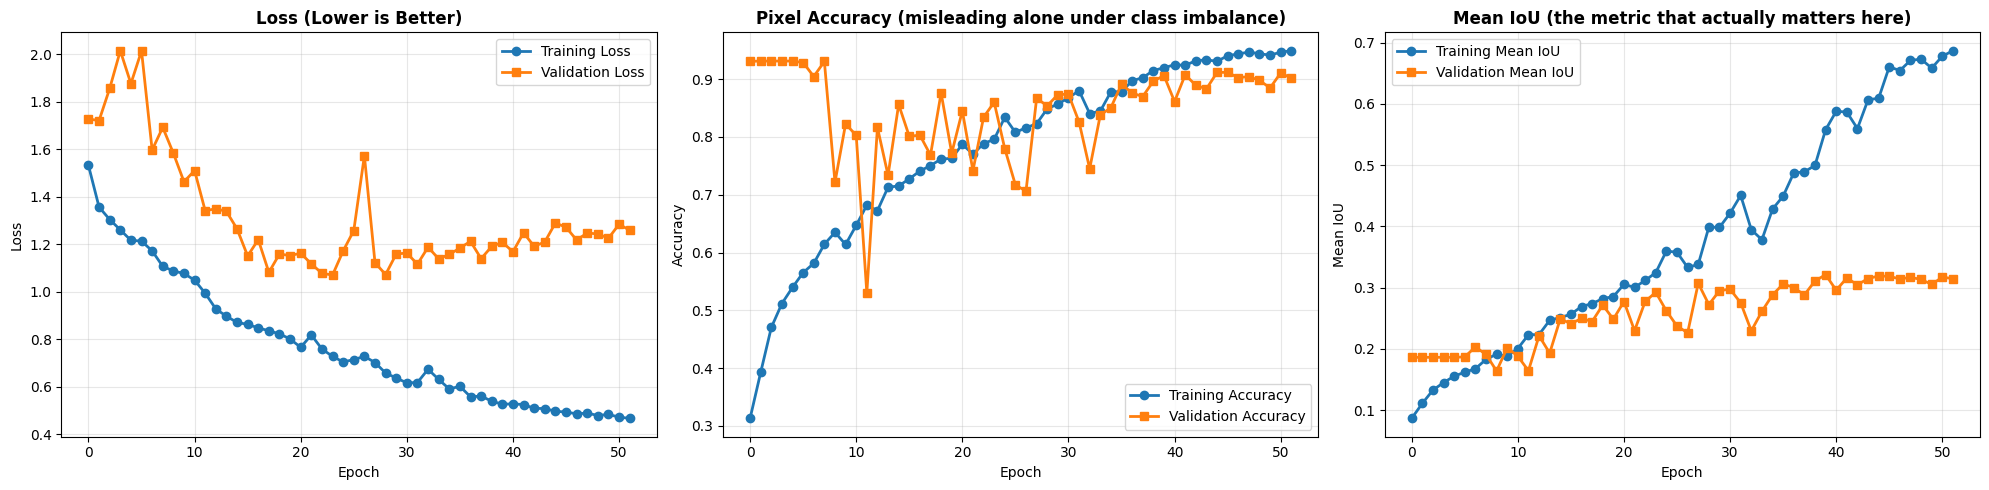

In [ ]:
fig, axes = plt.subplots(1, 3 if 'val_mean_iou' in history.history else 2, figsize=(20, 5) if 'val_mean_iou' in history.history else (14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_title('Loss (Lower is Better)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_title('Pixel Accuracy (misleading alone under class imbalance)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if 'val_mean_iou' in history.history:
    axes[2].plot(history.history['mean_iou'], label='Training Mean IoU', linewidth=2, marker='o')
    axes[2].plot(history.history['val_mean_iou'], label='Validation Mean IoU', linewidth=2, marker='s')
    axes[2].set_title('Mean IoU (the metric that actually matters here)', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Mean IoU')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 16: Validate Data Integrity

In [ ]:
print('\n=== DATA INTEGRITY CHECK ===')
print(f'Training data range: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'Validation data range: [{X_val.min():.3f}, {X_val.max():.3f}]')
print(f'Training mask values: {np.unique(y_train)}')
print(f'Validation mask values: {np.unique(y_val)}')
print(f'\nTraining mask class distribution:')
for class_id in range(5):
    count = (y_train == class_id).sum()
    pct = (count / y_train.size) * 100
    print(f'  Class {class_id}: {pct:6.2f}%')

print(f'\nValidation mask class distribution:')
for class_id in range(5):
    count = (y_val == class_id).sum()
    pct = (count / y_val.size) * 100
    print(f'  Class {class_id}: {pct:6.2f}%')


=== DATA INTEGRITY CHECK ===
Training data range: [0.000, 1.000]
Validation data range: [0.000, 1.000]
Training mask values: [0 1 2 3 4]
Validation mask values: [0 1 2 3 4]

Training mask class distribution:
  Class 0:  93.29%
  Class 1:   3.99%
  Class 2:   2.17%
  Class 3:   0.46%
  Class 4:   0.09%

Validation mask class distribution:
  Class 0:  93.11%
  Class 1:   4.68%
  Class 2:   1.74%
  Class 3:   0.37%
  Class 4:   0.10%


## Step 17: Test Predictions

Testing on 3 images...



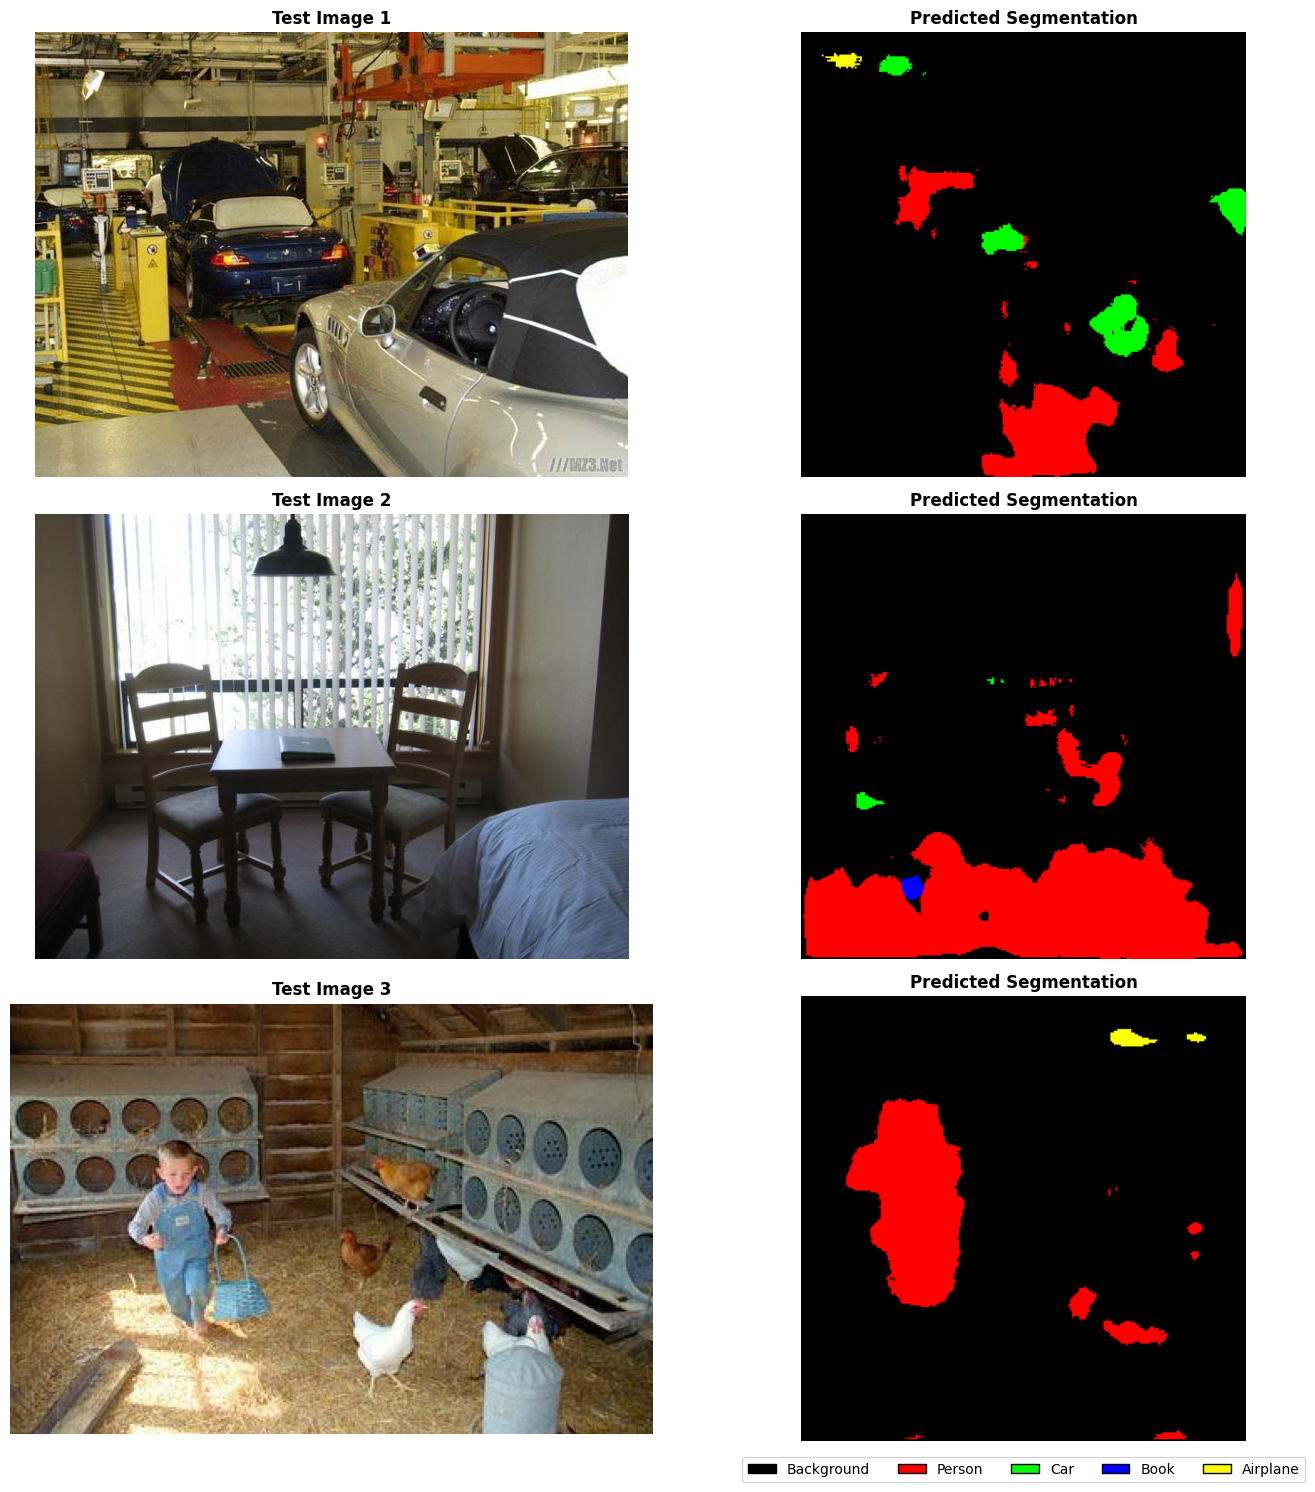

✓ Test evaluation complete!


In [ ]:
def predict_and_visualize(image_path, model, image_size=IMAGE_SIZE):
    image = io.imread(image_path)
    original_img = image.copy()

    image = cv2.resize(image, (image_size, image_size))
    image_norm = image / 255.0

    prediction = model.predict(np.expand_dims(image_norm, axis=0), verbose=0)
    predicted_mask = np.argmax(prediction[0], axis=-1)

    colored_mask = convert_mask_to_colored_image(predicted_mask, class_colors_rgb)

    return original_img, predicted_mask, colored_mask

test_images = sorted([f for f in os.listdir(test_data_path) if f.endswith('.jpg')])[:3]

print(f'Testing on {len(test_images)} images...\n')

fig, axes = plt.subplots(len(test_images), 2, figsize=(14, 5*len(test_images)))
if len(test_images) == 1:
    axes = axes.reshape(1, -1)

for idx, img_name in enumerate(test_images):
    img_path = os.path.join(test_data_path, img_name)
    original, pred_mask, colored_mask = predict_and_visualize(img_path, model)

    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f'Test Image {idx+1}', fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(colored_mask)
    axes[idx, 1].set_title('Predicted Segmentation', fontweight='bold')
    axes[idx, 1].axis('off')

# Legend
legend_elements = []
for class_id, class_name in enumerate(class_names):
    color_rgb = tuple(np.array(class_colors_rgb[class_id]) / 255.0)
    legend_elements.append(
        mpatches.Patch(facecolor=color_rgb, edgecolor='black', label=class_name.capitalize())
    )
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=5, frameon=True)

plt.tight_layout()
plt.show()

print('✓ Test evaluation complete!')

## Step 18: Evaluation Metrics

In [ ]:
print('\n=== FINAL METRICS ===' )
y_pred = model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=-1)

y_val_flat = y_val.flatten()
y_pred_flat = y_pred_classes.flatten()

overall_accuracy = (y_val_flat == y_pred_flat).mean()
overall_iou = jaccard_score(y_val_flat, y_pred_flat, average='weighted', zero_division=0)
overall_f1 = f1_score(y_val_flat, y_pred_flat, average='weighted', zero_division=0)

print('\nOVERALL METRICS:')
print(f'Pixel Accuracy: {overall_accuracy:.4f}')
print(f'Weighted IoU: {overall_iou:.4f}')
print(f'Weighted F1: {overall_f1:.4f}')

print('\nPER-CLASS METRICS:')
print('=' * 80)
for class_id, class_name in enumerate(class_names):
    mask_class = (y_val == class_id).flatten()
    pred_class = (y_pred_classes == class_id).flatten()

    if mask_class.sum() > 0:
        iou = jaccard_score(mask_class, pred_class, zero_division=0)
        f1 = f1_score(mask_class, pred_class, zero_division=0)
        if pred_class.sum() > 0:
            precision = (mask_class & pred_class).sum() / pred_class.sum()
        else:
            precision = 0
        pixels = mask_class.sum()
        print(f'{class_name:12s} | IoU: {iou:.4f} | F1: {f1:.4f} | Prec: {precision:.4f}')
print('=' * 80)


=== FINAL METRICS ===

OVERALL METRICS:
Pixel Accuracy: 0.9060
Weighted IoU: 0.8617
Weighted F1: 0.9148

PER-CLASS METRICS:
background   | IoU: 0.9037 | F1: 0.9494 | Prec: 0.9686
person       | IoU: 0.2883 | F1: 0.4475 | Prec: 0.3503
car          | IoU: 0.3819 | F1: 0.5527 | Prec: 0.5385
book         | IoU: 0.0321 | F1: 0.0622 | Prec: 0.0668
airplane     | IoU: 0.0000 | F1: 0.0000 | Prec: 0.0000


## Model 2: Pretrained-Encoder U-Net (Transfer Learning)

Across every tuning round on the from-scratch U-Net, the pattern has been consistent: person and car keep improving with more training/tuning (car IoU is now 0.38, the best yet), but **book (0.008 IoU) and airplane (0.0002 IoU) have not meaningfully improved -- if anything they got worse this round**. Given book is 0.46% and airplane is 0.09% of all training pixels, this looks like a genuine ceiling: a small U-Net trained from scratch on ~350 images simply doesn't see enough examples of these classes to learn what they look like from raw pixels.

**The fix that directly targets this:** use an encoder pretrained on ImageNet (MobileNetV2) instead of training convolutional filters from scratch. A pretrained encoder already knows general-purpose features -- edges, textures, shapes, object parts -- learned from millions of images. That means the model doesn't need hundreds of book/airplane examples to learn what makes them visually distinct; it can lean on transferable low- and mid-level features and only needs to learn how to *combine* them for our 5 classes.

This is also exactly what the assignment brief encourages: comparing a model you trained from scratch against a pretrained one, and discussing the difference -- good material for your Results and Methodology sections.

**Approach:**
1. Load MobileNetV2 pretrained on ImageNet as the encoder, **frozen** initially (only the decoder trains) -- this avoids overfitting the pretrained weights on our small, imbalanced dataset.
2. Reuse the same skip-connection U-Net decoder pattern as Model 1, and the same data pipeline (oversampling, augmentation, combined weighted CE + Dice loss) already built above.
3. Train the decoder with the backbone frozen; optionally fine-tune the top backbone layers afterwards at a low learning rate for a few epochs.
4. Evaluate with the same per-class metrics as Model 1, so the comparison is apples-to-apples.


In [ ]:
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2

def build_pretrained_unet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=5, freeze_backbone=True):
    """U-Net-style decoder on top of a MobileNetV2 encoder pretrained on ImageNet.
    Skip connections are taken at the same relative resolutions as the custom
    U-Net (Model 1) so the decoder design is directly comparable."""
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = not freeze_backbone

    skip_names = ['block_1_expand_relu', 'block_3_expand_relu',
                  'block_6_expand_relu', 'block_13_expand_relu']
    feature_extractor = keras.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(n).output for n in skip_names] + [base_model.output]
    )

    inputs = keras.Input(shape=input_shape)
    # Our data pipeline normalizes images to [0, 1] (see load_and_process_image).
    # MobileNetV2's pretrained weights expect their own preprocessing (roughly
    # [-1, 1]), so that conversion is bridged here rather than rebuilding the
    # whole data pipeline for this one model.
    x = layers.Rescaling(255.0)(inputs)
    x = layers.Lambda(mobilenet_v2.preprocess_input)(x)

    s1, s2, s3, s4, encoded = feature_extractor(x)
    skips = [s1, s2, s3, s4]

    d = encoded
    for skip, filters in zip(reversed(skips), [256, 128, 64, 32]):
        d = layers.UpSampling2D(2)(d)
        d = layers.concatenate([d, skip])
        d = layers.Conv2D(filters, 3, activation='relu', padding='same')(d)
        d = layers.BatchNormalization()(d)
        d = layers.Conv2D(filters, 3, activation='relu', padding='same')(d)
        d = layers.BatchNormalization()(d)

    d = layers.UpSampling2D(2)(d)  # back to full input resolution
    d = layers.Conv2D(16, 3, activation='relu', padding='same')(d)
    d = layers.BatchNormalization()(d)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d)

    return keras.Model(inputs=inputs, outputs=outputs), base_model

model2, backbone2 = build_pretrained_unet(freeze_backbone=True)
print(f'✓ Pretrained-encoder U-Net built')
print(f'Total params: {model2.count_params():,}')
print(f'Trainable params (decoder only, backbone frozen): '
      f'{sum(v.numpy().size for v in model2.trainable_variables):,}')


/tmp/ipykernel_554/2120410766.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Pretrained-encoder U-Net built
Total params: 8,045,989
Trainable params (decoder only, backbone frozen): 5,786,053


In [ ]:
model2_loss = make_weighted_ce_dice_loss(class_weights, num_classes=NUM_CLASSES, dice_weight=0.5)

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=model2_loss,
    metrics=['accuracy', keras.metrics.MeanIoU(num_classes=NUM_CLASSES, sparse_y_pred=False, name='mean_iou')]
)
print('✓ Model 2 compiled (backbone frozen, decoder trains at lr=1e-3)')


✓ Model 2 compiled (backbone frozen, decoder trains at lr=1e-3)


In [ ]:
early_stop2 = EarlyStopping(
    monitor='val_mean_iou', mode='max', patience=10, restore_best_weights=True, verbose=1
)
reduce_lr2 = ReduceLROnPlateau(
    monitor='val_mean_iou', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

print('=== Phase 1: training decoder, backbone frozen ===\n')
history2 = model2.fit(
    train_ds,           # reusing the same oversampled + augmented pipeline built for Model 1
    epochs=40,
    validation_data=val_ds,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)


=== Phase 1: training decoder, backbone frozen ===

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.3532 - loss: 1.0683 - mean_iou: 0.1206 - val_accuracy: 0.0627 - val_loss: 3.8578 - val_mean_iou: 0.0338 - learning_rate: 0.0010
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.6837 - loss: 0.8449 - mean_iou: 0.2312 - val_accuracy: 0.1473 - val_loss: 1.7813 - val_mean_iou: 0.0782 - learning_rate: 0.0010
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.7846 - loss: 0.7836 - mean_iou: 0.2827 - val_accuracy: 0.2221 - val_loss: 1.4831 - val_mean_iou: 0.1150 - learning_rate: 0.0010
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - accuracy: 0.8216 - loss: 0.7437 - mean_iou: 0.3140 - val_accuracy: 0.3054 - val_loss: 1.4601 - val_mean_iou: 0.1885 - learning_rate: 0.0010
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.8629 - loss: 0.6536 - mean_iou: 0.3752 - val_accuracy: 0.7325 - val_loss: 0.8564 - val_mean_iou: 0.2961 - l

In [ ]:
print('=== Phase 2: fine-tuning top backbone layers at a low learning rate ===\n')

# Unfreeze only the last ~20 layers of the backbone -- fine-tunes higher-level,
# more task-specific features while keeping low-level (edge/texture) features,
# which transfer well regardless of task, frozen and stable.
#
# Important: this must operate on `backbone2` (the original MobileNetV2 object
# returned from build_pretrained_unet), not a re-wrapped copy of it -- setting
# .trainable on a Model built by re-wrapping another model's layers does NOT
# reliably cascade to those shared layer objects in this Keras version. This
# was verified directly: re-wrapped unfreezing left the trainable parameter
# count completely unchanged, which would have silently fine-tuned nothing.
for layer in backbone2.layers:
    layer.trainable = True
for layer in backbone2.layers[:-20]:
    layer.trainable = False

print(f'Trainable params after unfreezing last 20 backbone layers: '
      f'{sum(v.numpy().size for v in model2.trainable_variables):,}')

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR for fine-tuning
    loss=model2_loss,
    metrics=['accuracy', keras.metrics.MeanIoU(num_classes=NUM_CLASSES, sparse_y_pred=False, name='mean_iou')]
)

early_stop2b = EarlyStopping(
    monitor='val_mean_iou', mode='max', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr2b = ReduceLROnPlateau(
    monitor='val_mean_iou', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

history2_ft = model2.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=[early_stop2b, reduce_lr2b],
    verbose=1
)

model2.save('segmentation_model_pretrained.keras')
print('\n✓ Model 2 saved!')


=== Phase 2: fine-tuning top backbone layers at a low learning rate ===

Trainable params after unfreezing last 20 backbone layers: 6,992,133
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9619 - loss: 0.3893 - mean_iou: 0.6788 - val_accuracy: 0.9493 - val_loss: 0.7110 - val_mean_iou: 0.5307 - learning_rate: 1.0000e-05
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.9605 - loss: 0.3596 - mean_iou: 0.6800 - val_accuracy: 0.9490 - val_loss: 0.6931 - val_mean_iou: 0.5305 - learning_rate: 1.0000e-05
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.9606 - loss: 0.3515 - mean_iou: 0.6754 - val_accuracy: 0.9497 - val_loss: 0.6979 - val_mean_iou: 0.5282 - learning_rate: 1.0000e-05
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9620 - loss: 0.3391 - mean_iou: 0.6295
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.9620 - loss: 0.3308 - mean_iou

In [ ]:
print('\n=== MODEL 2 (PRETRAINED ENCODER) FINAL METRICS ===')
y_pred2 = model2.predict(X_val, verbose=0)
y_pred2_classes = np.argmax(y_pred2, axis=-1)

y_val_flat = y_val.flatten()
y_pred2_flat = y_pred2_classes.flatten()

overall_accuracy2 = (y_val_flat == y_pred2_flat).mean()
overall_iou2 = jaccard_score(y_val_flat, y_pred2_flat, average='weighted', zero_division=0)
overall_f1_2 = f1_score(y_val_flat, y_pred2_flat, average='weighted', zero_division=0)

print(f'Pixel Accuracy: {overall_accuracy2:.4f}')
print(f'Weighted IoU:   {overall_iou2:.4f}')
print(f'Weighted F1:    {overall_f1_2:.4f}')

print('\nPER-CLASS METRICS -- MODEL 1 (custom U-Net) vs MODEL 2 (pretrained encoder):')
print('=' * 80)
print(f'{"class":12s} | {"Model1 IoU":>10s} | {"Model2 IoU":>10s} | {"Model1 F1":>10s} | {"Model2 F1":>10s}')

model1_iou_scores = {}
model2_iou_scores = {}
for class_id, class_name in enumerate(class_names):
    mask_class = (y_val == class_id).flatten()

    pred1_class = (y_pred_classes == class_id).flatten()  # from Model 1's evaluation cell above
    pred2_class = (y_pred2_classes == class_id).flatten()

    iou1 = jaccard_score(mask_class, pred1_class, zero_division=0) if mask_class.sum() > 0 else 0.0
    iou2 = jaccard_score(mask_class, pred2_class, zero_division=0) if mask_class.sum() > 0 else 0.0
    f1_1 = f1_score(mask_class, pred1_class, zero_division=0) if mask_class.sum() > 0 else 0.0
    f1_2 = f1_score(mask_class, pred2_class, zero_division=0) if mask_class.sum() > 0 else 0.0

    model1_iou_scores[class_name] = iou1
    model2_iou_scores[class_name] = iou2

    print(f'{class_name:12s} | {iou1:10.4f} | {iou2:10.4f} | {f1_1:10.4f} | {f1_2:10.4f}')
print('=' * 80)



=== MODEL 2 (PRETRAINED ENCODER) FINAL METRICS ===
Pixel Accuracy: 0.9493
Weighted IoU:   0.9173
Weighted F1:    0.9525

PER-CLASS METRICS -- MODEL 1 (custom U-Net) vs MODEL 2 (pretrained encoder):
class        | Model1 IoU | Model2 IoU |  Model1 F1 |  Model2 F1
background   |     0.9037 |     0.9468 |     0.9494 |     0.9727
person       |     0.2883 |     0.5114 |     0.4475 |     0.6767
car          |     0.3819 |     0.6013 |     0.5527 |     0.7510
book         |     0.0321 |     0.2723 |     0.0622 |     0.4280
airplane     |     0.0000 |     0.3217 |     0.0000 |     0.4868


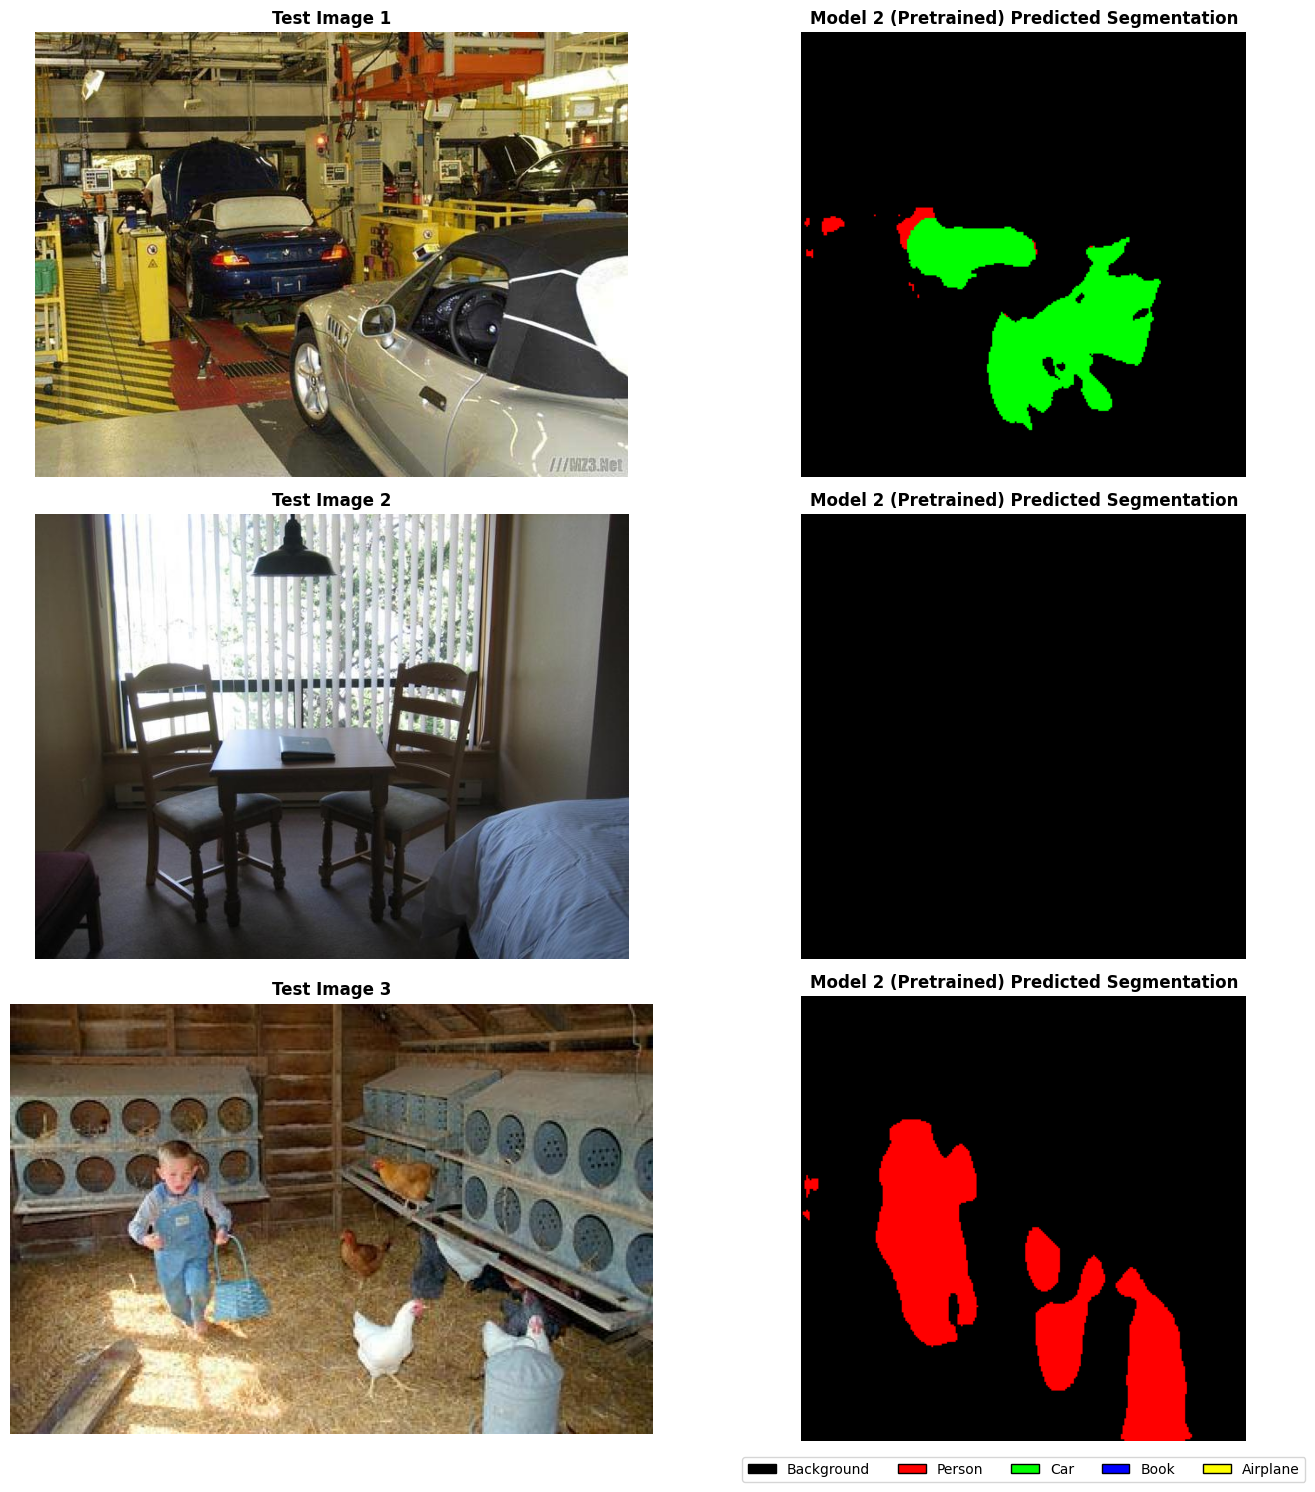

✓ Model 2 test evaluation complete!


In [ ]:
def predict_and_visualize_model(image_path, model, image_size=IMAGE_SIZE):
    image = io.imread(image_path)
    original_img = image.copy()
    image = cv2.resize(image, (image_size, image_size))
    image_norm = image / 255.0
    prediction = model.predict(np.expand_dims(image_norm, axis=0), verbose=0)
    predicted_mask = np.argmax(prediction[0], axis=-1)
    colored_mask = convert_mask_to_colored_image(predicted_mask, class_colors_rgb)
    return original_img, predicted_mask, colored_mask

fig, axes = plt.subplots(len(test_images), 2, figsize=(14, 5*len(test_images)))
if len(test_images) == 1:
    axes = axes.reshape(1, -1)

for idx, img_name in enumerate(test_images):
    img_path = os.path.join(test_data_path, img_name)
    original, pred_mask, colored_mask = predict_and_visualize_model(img_path, model2)

    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f'Test Image {idx+1}', fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(colored_mask)
    axes[idx, 1].set_title('Model 2 (Pretrained) Predicted Segmentation', fontweight='bold')
    axes[idx, 1].axis('off')

legend_elements = []
for class_id, class_name in enumerate(class_names):
    color_rgb = tuple(np.array(class_colors_rgb[class_id]) / 255.0)
    legend_elements.append(
        mpatches.Patch(facecolor=color_rgb, edgecolor='black', label=class_name.capitalize())
    )
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=5, frameon=True)

plt.tight_layout()
plt.show()
print('✓ Model 2 test evaluation complete!')


### Reading the comparison

If Model 2's book/airplane IoU is meaningfully higher than Model 1's, that confirms the hypothesis: those classes were bottlenecked by not having enough raw-pixel examples to learn generic visual features from scratch, and pretrained features close that gap. If Model 2 *also* struggles on book/airplane, that's stronger evidence the bottleneck is genuinely how few labelled examples exist in this 350-image subset (a dataset limitation, not a modelling one) -- either way, this comparison directly answers "why are the results as they are" for your report's critical-analysis section, which is exactly the discussion the brief is asking for.

A likely outcome worth anticipating: Model 2 may do noticeably better on person/car too (pretrained features generally help even well-represented classes), which is also worth discussing -- it would suggest the *whole* dataset is small enough that transfer learning helps broadly, not just for the rarest classes.
